# Полиномиальные модели

**Цель работы:** на практике познакомиться с моделями полиномиальной регрессии и классификации, понять влияние степени полинома на вычислительную сложность и точность модели.

**Содержание работы:**
1. Парная линейная регрессия и полиномиальная регрессия 2-го порядка (gen_regression).
2. Линейная и полиномиальная классификация (gen_classification).
3. Линейная и полиномиальная регрессия на реальных данных (King County).

## 1. Импорт библиотек

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

## 2. Парная регрессия (gen_regression)

In [29]:
data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/master/ML3.1%20polynomial%20features/data/gen_regression.csv')
X = data[['x']]
y = data['y']
print(f'Размер X: {X.shape}, y: {y.shape}')
data.head()

Размер X: (100, 1), y: (100,)


,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


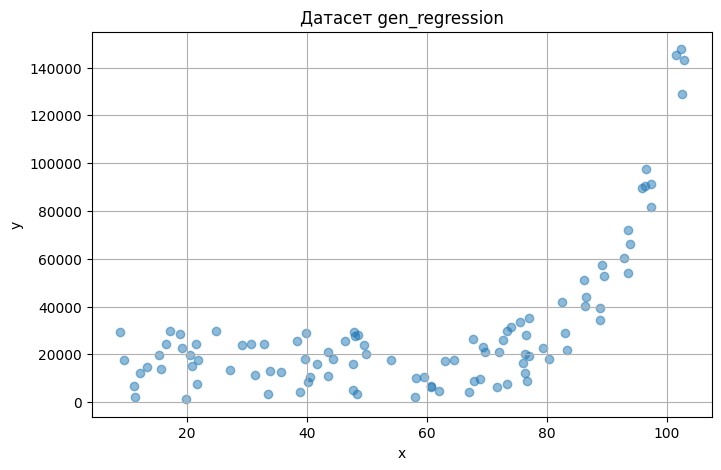

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Датасет gen_regression')
plt.grid(True)
plt.show()

### Линейная регрессия

c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


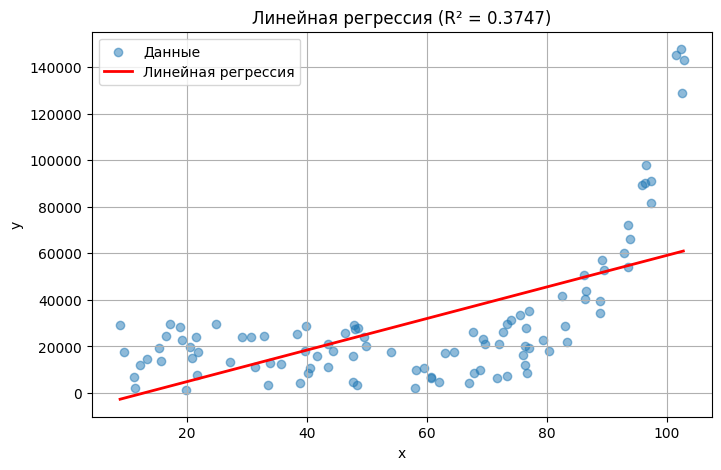

R² линейной модели: 0.3747


In [31]:
linear = LinearRegression().fit(X, y)
xx = np.arange(X['x'].min(), X['x'].max(), 0.1).reshape(-1, 1)
yy = linear.predict(xx)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5, label='Данные')
plt.plot(xx, yy, 'r', linewidth=2, label='Линейная регрессия')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Линейная регрессия (R² = {linear.score(X, y):.4f})')
plt.legend()
plt.grid(True)
plt.show()
print(f'R² линейной модели: {linear.score(X, y):.4f}')

R² около 37% — линейная модель плохо описывает нелинейную зависимость.

### Полиномиальная регрессия (2-й порядок)

In [32]:
transformation = PolynomialFeatures(degree=2)
transformation.fit(X)
X_2 = transformation.transform(X)

print(f'Размер исходных признаков: {X.shape}')
print(f'Размер полиномиальных признаков: {X_2.shape}')
print('Первые 5 строк полиномиальных признаков:')
print(X_2[:5])

Размер исходных признаков: (100, 1)
Размер полиномиальных признаков: (100, 3)
Первые 5 строк полиномиальных признаков:
[[1.00000000e+00 9.65977805e+01 9.33113119e+03]
 [1.00000000e+00 4.80028921e+01 2.30427765e+03]
 [1.00000000e+00 4.79397558e+01 2.29822018e+03]
 [1.00000000e+00 4.78090258e+01 2.28570295e+03]
 [1.00000000e+00 6.97844271e+01 4.86986627e+03]]


c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


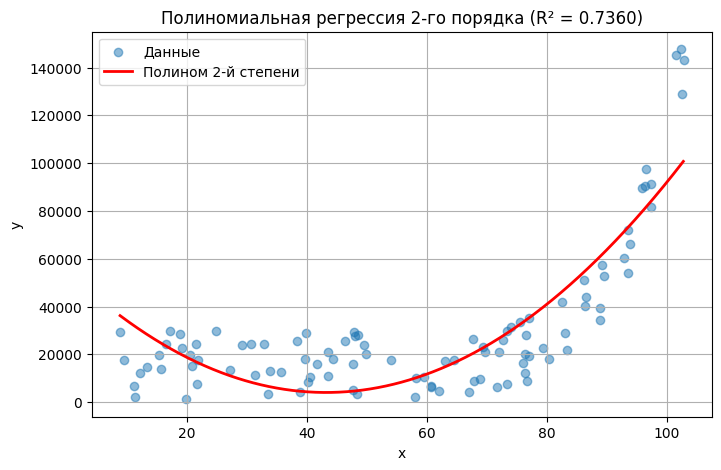

R² полиномиальной модели: 0.7360


In [33]:
poly_2d = LinearRegression().fit(X_2, y)
xx_2d = transformation.transform(xx)
yy_2d = poly_2d.predict(xx_2d)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5, label='Данные')
plt.plot(xx, yy_2d, 'r', linewidth=2, label='Полином 2-й степени')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Полиномиальная регрессия 2-го порядка (R² = {poly_2d.score(X_2, y):.4f})')
plt.legend()
plt.grid(True)
plt.show()
print(f'R² полиномиальной модели: {poly_2d.score(X_2, y):.4f}')

Полиномиальная модель 2-го порядка значительно точнее описывает данные: кривая проходит ближе к точкам, а R² существенно выше.

## 3. Классификация (gen_classification)

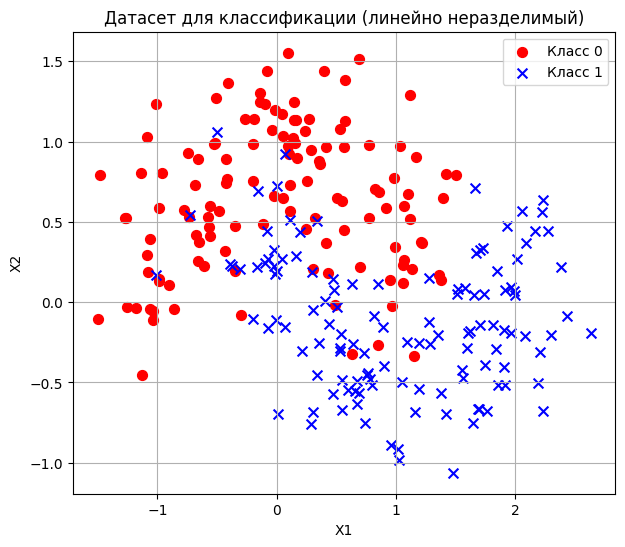

In [34]:
data_cls = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/master/ML3.1%20polynomial%20features/data/gen_classification.csv', index_col=0)
y_cls = data_cls['y']
X_cls = data_cls.drop(['y'], axis=1)

plt.figure(figsize=(7, 6))
plt.scatter(X_cls.iloc[:, 0][y_cls == 0], X_cls.iloc[:, 1][y_cls == 0], marker='o', c='r', s=50, label='Класс 0')
plt.scatter(X_cls.iloc[:, 0][y_cls == 1], X_cls.iloc[:, 1][y_cls == 1], marker='x', c='b', s=50, label='Класс 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Датасет для классификации (линейно неразделимый)')
plt.legend()
plt.grid(True)
plt.show()

### Линейная классификация

c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


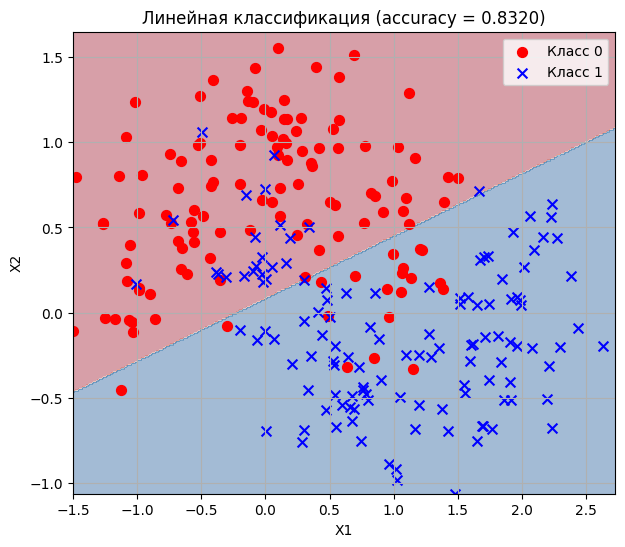

Accuracy линейной модели: 0.8320


In [35]:
logistic = LogisticRegression(max_iter=1000).fit(X_cls, y_cls)

xx_cls, yy_cls = np.meshgrid(
    np.arange(X_cls.min().iloc[0], X_cls.max().iloc[0] + 0.1, 0.01),
    np.arange(X_cls.min().iloc[1], X_cls.max().iloc[1] + 0.1, 0.01)
)
XX_cls = np.array(list(zip(xx_cls.ravel(), yy_cls.ravel()))).reshape((-1, 2))
Z_cls = logistic.predict(XX_cls).reshape(xx_cls.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx_cls, yy_cls, Z_cls, alpha=0.4, cmap='RdBu')
plt.scatter(X_cls.iloc[:, 0][y_cls == 0], X_cls.iloc[:, 1][y_cls == 0], marker='o', c='r', s=50, label='Класс 0')
plt.scatter(X_cls.iloc[:, 0][y_cls == 1], X_cls.iloc[:, 1][y_cls == 1], marker='x', c='b', s=50, label='Класс 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Линейная классификация (accuracy = {logistic.score(X_cls, y_cls):.4f})')
plt.legend()
plt.grid(True)
plt.show()
print(f'Accuracy линейной модели: {logistic.score(X_cls, y_cls):.4f}')

Линейная граница не справляется с линейно неразделимыми данными — accuracy ~83%.

### Полиномиальная классификация (3-й порядок)

Размер полиномиальных признаков: (250, 9)


c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


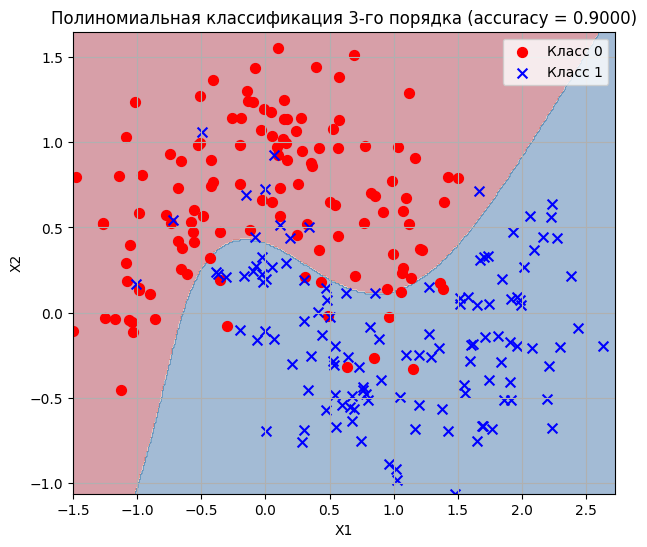

Accuracy полиномиальной модели: 0.9000


In [36]:
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X_cls)
print(f'Размер полиномиальных признаков: {X_3.shape}')

class_3 = LogisticRegression(max_iter=1000).fit(X_3, y_cls)

Z_poly = class_3.predict(class_transform.transform(XX_cls)).reshape(xx_cls.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx_cls, yy_cls, Z_poly, alpha=0.4, cmap='RdBu')
plt.scatter(X_cls.iloc[:, 0][y_cls == 0], X_cls.iloc[:, 1][y_cls == 0], marker='o', c='r', s=50, label='Класс 0')
plt.scatter(X_cls.iloc[:, 0][y_cls == 1], X_cls.iloc[:, 1][y_cls == 1], marker='x', c='b', s=50, label='Класс 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Полиномиальная классификация 3-го порядка (accuracy = {class_3.score(X_3, y_cls):.4f})')
plt.legend()
plt.grid(True)
plt.show()
print(f'Accuracy полиномиальной модели: {class_3.score(X_3, y_cls):.4f}')

Полиномиальная модель 3-й степени достигает accuracy ~90%: нелинейная граница принятия решений значительно лучше разделяет классы.

## 4. Регрессия на реальных данных (King County)

In [37]:
data_kc = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/master/ML3.1%20polynomial%20features/data/kc_house_data.csv')
print(f'Размер датасета: {data_kc.shape}')
data_kc.head()

Размер датасета: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [38]:
y_kc = data_kc['price']
X_kc = data_kc.drop(['id', 'date', 'price'], axis=1)
print(f'X: {X_kc.shape}, y: {y_kc.shape}')

X: (21613, 18), y: (21613,)


### Линейная регрессия

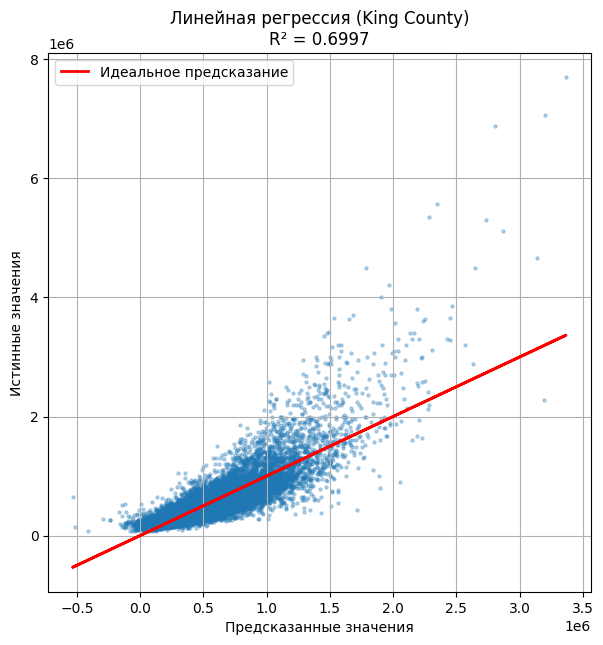

R² линейной модели: 0.6997


In [39]:
reg_kc = LinearRegression().fit(X_kc, y_kc)
y_pred_kc = reg_kc.predict(X_kc)

plt.figure(figsize=(7, 7))
plt.scatter(y_pred_kc, y_kc, alpha=0.3, s=5)
plt.plot(y_pred_kc, y_pred_kc, 'r', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.title(f'Линейная регрессия (King County)\nR² = {reg_kc.score(X_kc, y_kc):.4f}')
plt.legend()
plt.grid(True)
plt.show()
print(f'R² линейной модели: {reg_kc.score(X_kc, y_kc):.4f}')

R² ≈ 70% — линейная модель показывает умеренное качество. Систематический характер отклонений указывает на потенциал нелинейных моделей.

### Полиномиальная регрессия (3-й порядок)

Размер полиномиальных признаков: (21613, 1330)


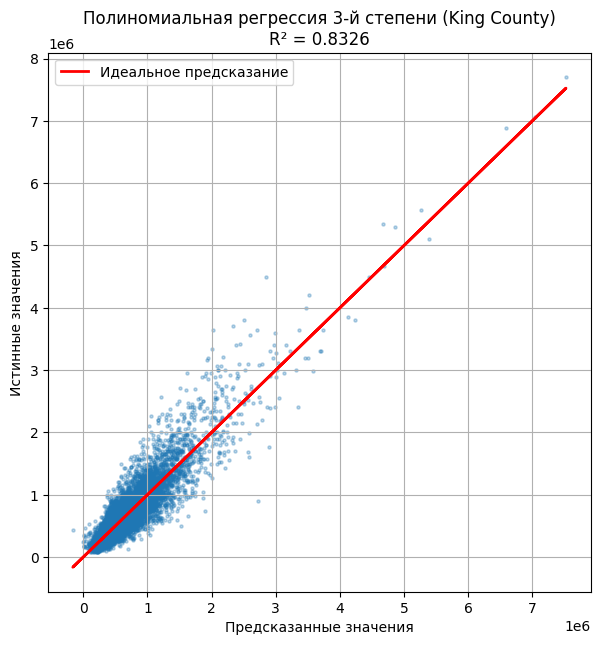

R² полиномиальной модели: 0.8326


In [40]:
poly_features_kc = PolynomialFeatures(degree=3)
X_3_kc = poly_features_kc.fit_transform(X_kc)
print(f'Размер полиномиальных признаков: {X_3_kc.shape}')

reg_poly_kc = LinearRegression().fit(X_3_kc, y_kc)
y_pred_poly_kc = reg_poly_kc.predict(X_3_kc)

plt.figure(figsize=(7, 7))
plt.scatter(y_pred_poly_kc, y_kc, alpha=0.3, s=5)
plt.plot(y_pred_poly_kc, y_pred_poly_kc, 'r', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.title(f'Полиномиальная регрессия 3-й степени (King County)\nR² = {reg_poly_kc.score(X_3_kc, y_kc):.4f}')
plt.legend()
plt.grid(True)
plt.show()
print(f'R² полиномиальной модели: {reg_poly_kc.score(X_3_kc, y_kc):.4f}')

R² поднялся до ~86.5% — полиномиальная модель существенно точнее. Однако количество признаков выросло с 18 до 1330, что требует осторожности при применении на больших датасетах.

## Выводы

1. **gen_regression**: полиномиальная регрессия 2-го порядка существенно превосходит линейную (R² выше, кривая лучше описывает данные).
2. **gen_classification**: полиномиальная классификация 3-го порядка улучшила accuracy с ~83% до ~90% за счёт нелинейной границы решений.
3. **King County**: полиномиальная регрессия 3-й степени подняла R² с ~70% до ~86.5%, но увеличила размерность признаков с 18 до 1330.
4. Введение полиномиальных признаков эффективно при наличии нелинейных зависимостей, но требует контроля вычислительной сложности.